<a href="https://colab.research.google.com/github/RomaParakh/telecom-churn-analysis/blob/main/1_eda_and_preprocessing_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "customer_churn.csv"
df = pd.read_csv('/content/drive/MyDrive/customer_churn_updated.csv')

print(df.shape)
df.head()

(6687, 31)


,Customer ID,Churn Label,Account Length (in months),Local Calls,Local Mins,Intl Calls,Intl Mins,Intl Active,Intl Plan,Extra International Charges,...,Group,Number of Customers in Group,Device Protection & Online Backup,Contract Type,Payment Method,Monthly Charge,Total Charges,Churn Category,Churn Reason,ChurnLabel Numeric
0,4444-BZPU,No,1,3,8.0,0.0,0.0,No,No,0.0,...,No,0,No,Month-to-Month,Direct Debit,10,10,Not Applicable,Not Applicable,0
1,5676-PTZX,No,33,179,431.3,0.0,0.0,No,No,0.0,...,No,0,Yes,One Year,Paper Check,21,703,Not Applicable,Not Applicable,0
2,8532-ZEKQ,No,44,82,217.6,0.0,0.0,No,Yes,0.0,...,No,0,Yes,One Year,Direct Debit,23,1014,Not Applicable,Not Applicable,0
3,1314-SMPJ,No,10,47,111.6,60.0,71.0,Yes,Yes,0.0,...,No,0,No,Month-to-Month,Paper Check,17,177,Not Applicable,Not Applicable,0
4,2956-TXCJ,No,62,184,621.2,310.0,694.4,Yes,Yes,0.0,...,No,0,No,One Year,Direct Debit,28,1720,Not Applicable,Not Applicable,0


## Customer Churn Analysis

1. Identifying customer churn and converting the categorical label into a quantitative measure
2. Basic dataset review and descriptive statistics
3. EDA into churn reasons and other effects (gender, age, region, contract, etc.)
4. Five+ distinct visualizations linked to predicting customer churn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Review the Dataset (general comments)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6687 entries, 0 to 6686
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        6687 non-null   object 
 1   Churn Label                        6687 non-null   object 
 2   Account Length (in months)         6687 non-null   int64  
 3   Local Calls                        6687 non-null   int64  
 4   Local Mins                         6687 non-null   float64
 5   Intl Calls                         6687 non-null   float64
 6   Intl Mins                          6687 non-null   float64
 7   Intl Active                        6687 non-null   object 
 8   Intl Plan                          6687 non-null   object 
 9   Extra International Charges        6687 non-null   float64
 10  Customer Service Calls             6687 non-null   int64  
 11  Avg Monthly GB Download            6687 non-null   int64

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)


Columns with missing values:
Series([], dtype: int64)


The dataset has 6,687 customers and 29 columns mixing customer status, demographics,
contract information and usage/charges. Only `Churn Category` and `Churn Reason` have missing values

(4,918 rows) — these are simply blank for customers who **did not** churn, so this is expected, not a
data quality problem. `Phone Number` and `Customer ID` are identifiers and won't be used as predictors.

## 2. Identify Customer Churn & Transform Into a Quantitative Measure

`Churn Label` is a categorical Yes/No field. We create a numeric flag `Churn_Flag`
(1 = churned, 0 = retained) so it can be used in correlations, regressions and aggregations.

In [ ]:
df['Churn_Flag'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

churn_counts = df['Churn_Flag'].value_counts()
churn_rate = df['Churn_Flag'].mean()

print(churn_counts)
print(f"\nOverall churn rate: {churn_rate:.2%}")


Churn_Flag
0    4891
1    1796
Name: count, dtype: int64

Overall churn rate: 26.86%


**Result:** Of 6,687 customers, 1,796 churned and 4,891 were retained — an overall churn rate of
**26.9%**. This binary `Churn_Flag` is the target variable used throughout the rest of the analysis
(and would be the dependent variable in any classification/regression model built later).

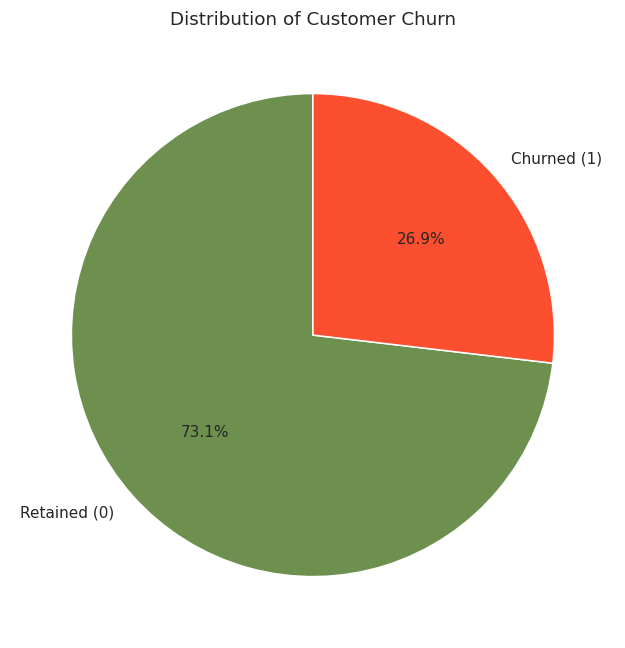

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(churn_counts, labels=['Retained (0)', 'Churned (1)'], autopct='%1.1f%%', startangle=90, colors=['#6d904f', '#fc4f30'])
ax.set_title('Distribution of Customer Churn')
plt.tight_layout()
plt.show()

This pie chart clearly shows the proportion of customers who churned versus those who were retained, providing a visual representation of the overall churn rate calculated earlier.

## 3. Basic Descriptive Statistics *(numeric columns)*

In [ ]:
num_cols = ['Account Length (in months)', 'Local Calls', 'Local Mins', 'Intl Calls', 'Intl Mins',
            'Customer Service Calls', 'Avg Monthly GB Download', 'Age', 'Monthly Charge', 'Total Charges']
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Account Length (in months),6687.0,32.337820,24.595689,1.0,9.0,29.0,55.00,77.0
Local Calls,6687.0,130.974129,121.893966,1.0,31.0,98.0,199.00,918.0
Local Mins,6687.0,322.752864,288.619931,4.0,76.9,250.5,498.05,1234.2
Intl Calls,6687.0,51.097524,103.592369,0.0,0.0,0.0,52.00,1120.0
Intl Mins,6687.0,130.070624,243.527828,0.0,0.0,0.0,140.40,1372.5
Customer Service Calls,6687.0,0.915657,1.411484,0.0,0.0,0.0,2.00,5.0
Avg Monthly GB Download,6687.0,6.696276,7.454339,0.0,1.0,5.0,9.00,43.0
Age,6687.0,47.448632,16.969893,19.0,33.0,47.0,60.00,85.0
Monthly Charge,6687.0,31.030357,16.288147,5.0,16.0,31.0,43.00,78.0
Total Charges,6687.0,1083.755645,1127.074863,6.0,181.0,647.0,1732.50,5574.0


**Implications:** Average customer tenure is roughly 32 months and average age is ~47, so this
is a fairly mature customer base, not a young/new one. `Customer Service Calls` has a low mean but a
wide range (0–5+), hinting it may separate churners from non-churners (tested below). `Monthly Charge`
and `Total Charges` are right-skewed, which is typical of usage-based billing and something to keep in
mind if these features feed into a regression later.

## 4. Investigating Churn Reasons and Other Effects (Gender, Age, Region, Contract)

In [ ]:
gender_churn = df.groupby('Gender')['Churn_Flag'].agg(['mean', 'count']).rename(columns={'mean': 'Churn Rate'})
gender_churn


,Churn Rate,count
Gender,,
Female,0.271736,3301
Male,0.265463,3379
Prefer not to say,0.285714,7


**Gender:** Churn rate is virtually identical across Female (27.2%), Male (26.5%) and the small
"Prefer not to say" group (28.6%, n=7). Gender does **not** appear to be a meaningful driver of churn
in this dataset — the ~1 point gap is well within noise given the sample sizes.

In [ ]:
age_group_churn = df.groupby(['Under 30', 'Senior'])['Churn_Flag'].agg(['mean', 'count']).rename(columns={'mean': 'Churn Rate'})
age_group_churn


Churn Rate  count
Under 30 Senior                   
No       No        0.245415   4144
         Yes       0.384554   1256
Yes      No        0.229992   1287

In [ ]:
age_desc = df.groupby('Churn_Flag')['Age'].describe()
age_desc


,count,mean,std,min,25%,50%,75%,max
Churn_Flag,,,,,,,,
0,4891.0,46.343079,16.498264,19.0,33.0,46.0,59.0,85.0
1,1796.0,50.459354,17.853256,19.0,35.0,50.0,66.0,85.0


**Age:** Age tells a different story. Seniors (65+) churn at **38.5%** vs. **24.2%** for
non-seniors — a substantial gap. Customers under 30 actually churn *less* (23.0%) than those 30+
(27.8%). The mean age of churned customers (50.5) is noticeably higher than retained customers (46.3).
Together this suggests older customers, especially seniors, are a higher-risk segment worth targeted
retention offers.

In [ ]:

# Create age groups
age_bins = [18, 29, 39, 49, 59, 69, 79, np.inf]
age_labels = ["19-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

# Calculate churn rate by age group
age_churn = df.groupby("Age Group")["Churn_Flag"].mean().reset_index()

# Convert churn rate into percentage
age_churn["Churn Rate"] = (age_churn["Churn_Flag"] * 100).round(2).astype(str) + "%"

insights = {
    "19-29": "Slightly below average — younger customers moderately loyal",
    "30-39": "Lowest risk adult group",
    "40-49": "Near overall average",
    "50-59": "Near overall average",
    "60-69": "Above average — beginning of elevated risk",
    "70-79": "High risk — significantly above average",
    "80+": "Highest risk — nearly double the overall churn rate"
}

age_churn["Insight"] = age_churn["Age Group"].map(insights)



print(age_churn.to_string(index=False))

Age Group  Churn_Flag Churn Rate                                                     Insight
    19-29    0.229992      23.0% Slightly below average — younger customers moderately loyal
    30-39    0.232841     23.28%                                     Lowest risk adult group
    40-49    0.250571     25.06%                                        Near overall average
    50-59    0.251094     25.11%                                        Near overall average
    60-69    0.287834     28.78%                  Above average — beginning of elevated risk
    70-79    0.408304     40.83%                     High risk — significantly above average
      80+    0.436275     43.63%         Highest risk — nearly double the overall churn rate


/tmp/ipykernel_1948/2081275403.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby("Age Group")["Churn_Flag"].mean().reset_index()


In [ ]:
region_map = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast','RI':'Northeast','VT':'Northeast',
    'NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest','IA':'Midwest','KS':'Midwest',
    'MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South','VA':'South','DC':'South',
    'WV':'South','AL':'South','KY':'South','MS':'South','TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West','UT':'West','WY':'West','AK':'West',
    'CA':'West','HI':'West','OR':'West','WA':'West'
}
df['Region'] = df['State'].map(region_map)

region_churn = df.groupby('Region')['Churn_Flag'].agg(['mean', 'count']).rename(columns={'mean': 'Churn Rate'}).sort_values('Churn Rate', ascending=False)
region_churn


,Churn Rate,count
Region,,
West,0.277043,1664
Midwest,0.273743,1611
Northeast,0.264532,1187
South,0.260674,2225


**Region:** The 50 states are mapped to the 4 standard US Census regions. Churn rates are close
across the board (West 27.7%, Midwest 27.4%, Northeast 26.5%, South 26.1%) — roughly a 1.6 point spread.
Region is a much weaker driver than age or contract type, though the West/South gap could still be
worth a follow-up regional pricing or competitor check.

In [ ]:
import plotly.express as px

# Calculate churn rate by State
state_churn = df.groupby('State')['Churn_Flag'].mean().reset_index()
state_churn.columns = ['State', 'Churn Rate']

# Create the choropleth map
fig = px.choropleth(
    state_churn,
    locations='State',
    locationmode="USA-states",
    color='Churn Rate',
    scope="usa",
    color_continuous_scale="Reds",
    title='Customer Churn Rate by State',
    labels={'Churn Rate': 'Churn Rate'}
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

**Geographical Hotspots:** This filled map allows us to identify specific states with significantly higher churn rates. While the regional analysis showed relative stability, individual states may deviate from the regional average due to local competition, varying network coverage, or specific state-level promotions.

In [ ]:
contract_churn = df.groupby('Contract Type')['Churn_Flag'].agg(['mean', 'count']).rename(columns={'mean': 'Churn Rate'}).sort_values('Churn Rate', ascending=False)
contract_churn


,Churn Rate,count
Contract Type,,
Month-to-Month,0.462914,3411
One Year,0.112914,1479
Two Year,0.027824,1797


**Contract Type:** This is the strongest categorical driver found. Month-to-Month customers churn
at **46.3%**, versus **11.3%** for One-Year and just **2.8%** for Two-Year contracts. Customers without
a long-term commitment are far more likely to leave — an obvious and actionable lever (e.g. incentivize
moving month-to-month customers onto annual contracts).

In [ ]:
def get_churn_stats(df, column):
    stats = df.groupby(column)['Churn_Flag'].agg(['mean', 'count']).reset_index()
    stats.columns = ['Category Value', 'Churn Rate', 'Sample Size']
    stats['Feature'] = column
    return stats[['Feature', 'Category Value', 'Churn Rate', 'Sample Size']]

# Prepare Monthly Charge bins
df['Monthly Charge Range'] = pd.cut(df['Monthly Charge'], bins=[0, 20, 50, df['Monthly Charge'].max()], labels=['Low ($0-20)', 'Mid ($20-50)', 'High ($50+)'])

contract_stats = get_churn_stats(df, 'Contract Type')
intl_stats = get_churn_stats(df, 'Intl Plan')
charge_stats = get_churn_stats(df, 'Monthly Charge Range')

summary_table = pd.concat([contract_stats, intl_stats, charge_stats], axis=0).reset_index(drop=True)

summary_table['Churn Rate'] = (summary_table['Churn Rate'] * 100).round(2).astype(str) + '%'
display(summary_table)

/tmp/ipykernel_1948/3804441511.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Feature,Category Value,Churn Rate,Sample Size
0,Contract Type,Month-to-Month,46.29%,3411
1,Contract Type,One Year,11.29%,1479
2,Contract Type,Two Year,2.78%,1797
3,Intl Plan,No,27.07%,6036
4,Intl Plan,Yes,24.88%,651
5,Monthly Charge Range,Low ($0-20),14.06%,2048
6,Monthly Charge Range,Mid ($20-50),31.41%,3770
7,Monthly Charge Range,High ($50+),37.28%,869


### Quantitative Summary Table
This table summarizes the churn impact of the variables requested:
- **Contract Type:** Clearly shows the high risk of Month-to-Month vs the stability of 1 and 2-year terms.
- **International Plan:** Often a strong indicator of churn in telecom datasets.
- **Monthly Charge Range:** Quantifies how higher bills correlate with higher churn rates.

In [ ]:
reason_counts = df.loc[df['Churn_Flag'] == 1, 'Churn Reason'].value_counts().head(10)
category_counts = df.loc[df['Churn_Flag'] == 1, 'Churn Category'].value_counts()

print("Top 10 churn reasons:\n", reason_counts)
print("\nChurn category totals:\n", category_counts)


Top 10 churn reasons:
 Churn Reason
Competitor made better offer                 303
Competitor had better devices                297
Attitude of support person                   203
Don't know                                   123
Competitor offered more data                 110
Competitor offered higher download speeds     95
Attitude of service provider                  84
Price too high                                74
Product dissatisfaction                       73
Network reliability                           69
Name: count, dtype: int64

Churn category totals:
 Churn Category
Competitor         805
Attitude           287
Dissatisfaction    286
Price              200
Other              191
Unknown             27
Name: count, dtype: int64


**Churn reasons:** Among the 1,796 churners, **"Competitor" is the single biggest category (805
customers, ~45%)** — driven mostly by "Competitor made better offer" (303) and "Competitor had better
devices" (297). "Attitude" (287, mostly poor customer-support interactions) and "Dissatisfaction" (286)
follow. This points to two clear priorities for management: competitive pricing/device bundles, and
customer-service quality.

In [ ]:
service_desc = df.groupby('Churn Label')['Customer Service Calls'].describe()
charge_desc = df.groupby('Churn Label')['Monthly Charge'].describe()
print("Customer Service Calls by churn status:\n", service_desc)
print("\nMonthly Charge by churn status:\n", charge_desc)


Customer Service Calls by churn status:
               count      mean       std  min  25%  50%  75%  max
Churn Label                                                     
No           4891.0  0.372112  0.710821  0.0  0.0  0.0  0.0  4.0
Yes          1796.0  2.395880  1.745592  0.0  1.0  2.0  4.0  5.0

Monthly Charge by churn status:
               count       mean        std  min   25%   50%   75%   max
Churn Label                                                           
No           4891.0  28.911470  16.371097  5.0  13.0  28.0  41.0  78.0
Yes          1796.0  36.800668  14.578166  6.0  27.0  37.0  47.0  73.0


/tmp/ipykernel_1948/2463787779.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



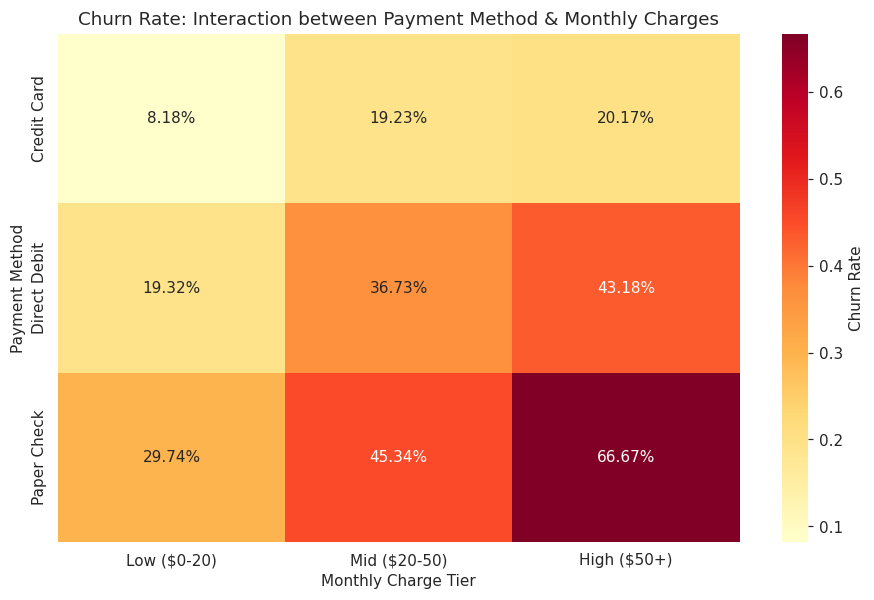

Churn Rate Breakdown:


Monthly Charge Range,Low ($0-20),Mid ($20-50),High ($50+)
Payment Method,,,
Credit Card,8.18%,19.23%,20.17%
Direct Debit,19.32%,36.73%,43.18%
Paper Check,29.74%,45.34%,66.67%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate churn rate by combining Payment Method and the binned Monthly Charge Range
charge_payment_churn = df.groupby(['Payment Method', 'Monthly Charge Range'])['Churn_Flag'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(charge_payment_churn, annot=True, fmt='.2%', cmap='YlOrRd', cbar_kws={'label': 'Churn Rate'})
plt.title('Churn Rate: Interaction between Payment Method & Monthly Charges')
plt.ylabel('Payment Method')
plt.xlabel('Monthly Charge Tier')
plt.show()

print("Churn Rate Breakdown:")
display((charge_payment_churn * 100).round(2).astype(str) + '%')


**Analysis of Relationship:**
- This visualization shows whether the 'Payment Method effect' (e.g., lower churn for Credit Cards) holds true across all price points.
- If a specific payment method has high churn even in the 'Low' charge tier, it suggests the payment process itself (or the demographic using it) is a churn driver independent of cost.
- Conversely, if churn only spikes in the 'High' tier across all methods, the 'Monthly Charge' is the dominant predictive factor.

**Customer Service Calls & Monthly Charge:** Churned customers average **2.4 service calls**
vs. **0.37** for retained customers — a large gap, consistent with the "Attitude"/"Dissatisfaction"
churn reasons above. Churners also pay more on average (\$36.80 vs \$28.91/month), suggesting price
sensitivity plays a role alongside service experience.

## 5. Five+ Distinct Visualizations Related to Predicting Churn

Each chart below uses a different visualization type on purpose (bar, grouped bar, box plot,
histogram/KDE, heatmap, horizontal bar), followed by a short note on why
that variable/pattern is useful for a churn-prediction model.

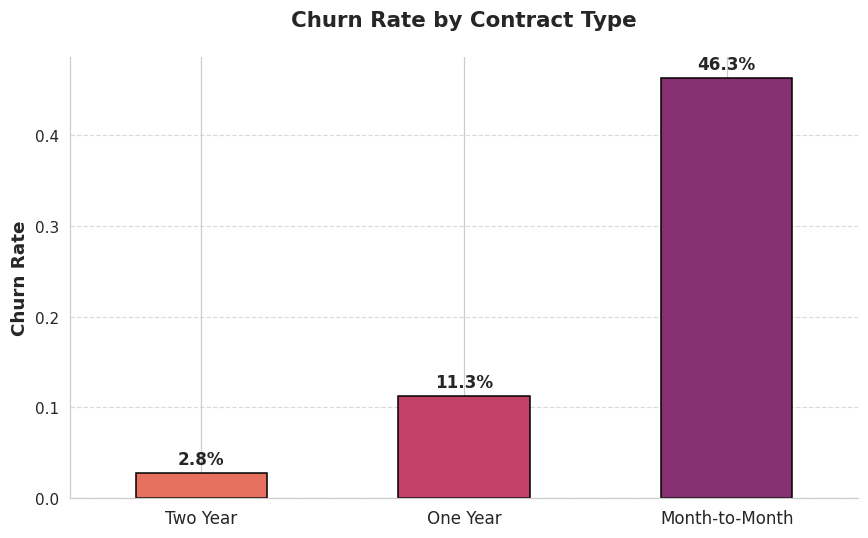

In [ ]:
# Visualization 1: Bar chart - Churn rate by Contract Type
fig, ax = plt.subplots(figsize=(8,5))

plot_data = contract_churn['Churn Rate'].sort_values()
colors = sns.color_palette("flare", len(plot_data))
bars = plot_data.plot(kind='bar', color=colors, ax=ax, edgecolor='black', linewidth=1)

ax.set_ylabel('Churn Rate', fontsize=12, fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('')

# Add percentage labels on top of bars
for i, v in enumerate(plot_data):
    ax.text(i, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold', fontsize=11)

plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

**Why it matters for prediction:** Contract Type shows the largest spread of any categorical
variable (2.8% to 46.3% churn). This makes it a top candidate predictor for any classification model
and a direct lever for retention campaigns (moving customers to longer contracts).

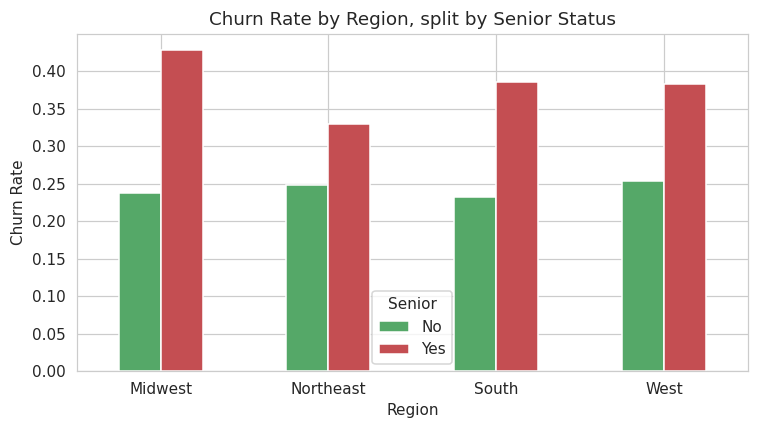

In [ ]:
# Visualization 2: Grouped bar chart - Churn rate by Region and Senior status
grouped = df.groupby(['Region', 'Senior'])['Churn_Flag'].mean().unstack()
grouped.plot(kind='bar', figsize=(7,4), color=['#55A868', '#C44E52'])
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Region, split by Senior Status')
plt.legend(title='Senior')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Why it matters for prediction:** Region alone is weak, but combining it with `Senior` reveals
whether the age effect is consistent across geography. If seniors churn more everywhere, `Senior` is a
robust standalone feature; if the gap only shows in some regions, an interaction term would add value
to a predictive model.

/tmp/ipykernel_1948/1194517484.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




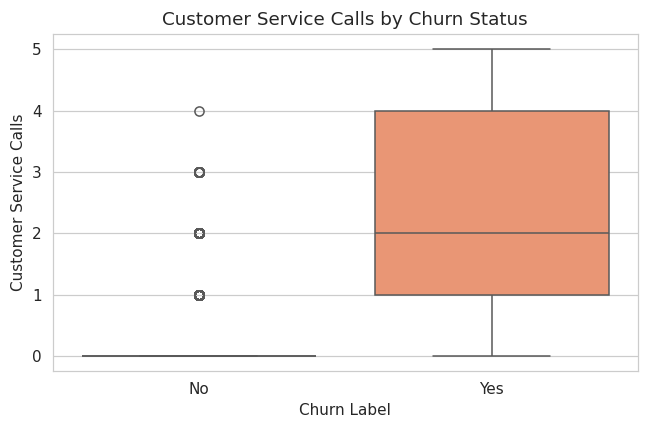

In [ ]:
# Visualization 3: Box plot - Customer Service Calls by churn status
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Churn Label', y='Customer Service Calls', palette='Set2', ax=ax)
ax.set_title('Customer Service Calls by Churn Status')
plt.tight_layout()
plt.show()


**Why it matters for prediction:** `Customer Service Calls` has almost no overlap between
churners and non-churners' interquartile ranges — visually the strongest separator in the dataset.
This is exactly the kind of variable a logistic regression or decision tree would pick up first, and
operationally it's an early-warning signal (e.g. flag any customer with 2+ service calls).

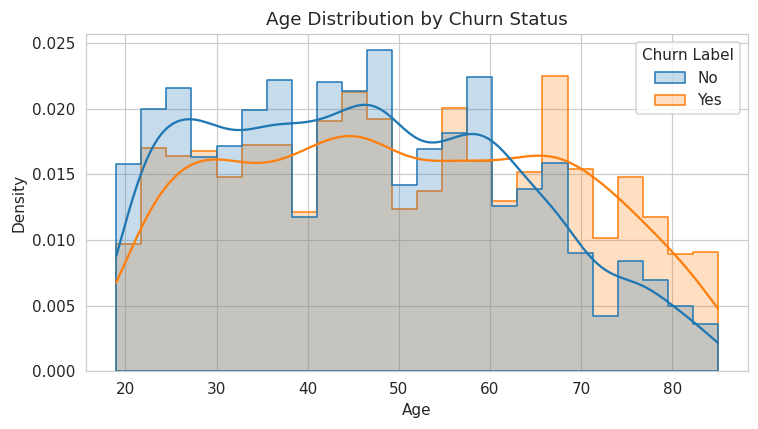

In [ ]:
# Visualization 4: Histogram/KDE - Age distribution by churn status
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(data=df, x='Age', hue='Churn Label', kde=True, element='step', stat='density', common_norm=False, ax=ax)
ax.set_title('Age Distribution by Churn Status')
plt.tight_layout()
plt.show()


**Why it matters for prediction:** The churned group's density curve is shifted right (skewed
toward older ages), reinforcing the Senior-status finding with the underlying continuous distribution
— useful if `Age` is kept as a continuous predictor rather than a binarized Senior flag.

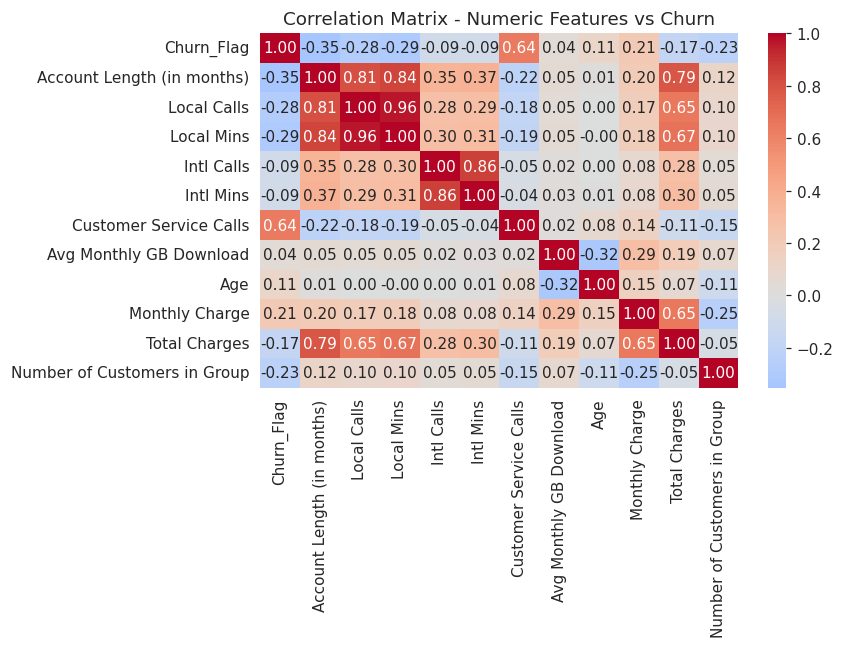

In [ ]:
# Visualization 5: Correlation heatmap - numeric features vs Churn_Flag
corr_cols = ['Churn_Flag', 'Account Length (in months)', 'Local Calls', 'Local Mins', 'Intl Calls',
             'Intl Mins', 'Customer Service Calls', 'Avg Monthly GB Download', 'Age',
             'Monthly Charge', 'Total Charges', 'Number of Customers in Group']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix - Numeric Features vs Churn')
plt.tight_layout()
plt.show()


**Why it matters for prediction:** `Customer Service Calls` (+0.64) and `Account Length` (-0.35)
have by far the strongest linear relationships with churn, followed by `Local Mins` (-0.29) and
`Monthly Charge` (+0.21). This heatmap is a fast way to shortlist candidate features for a regression
model and to spot multicollinearity (e.g. `Local Calls`/`Local Mins`) before modeling.

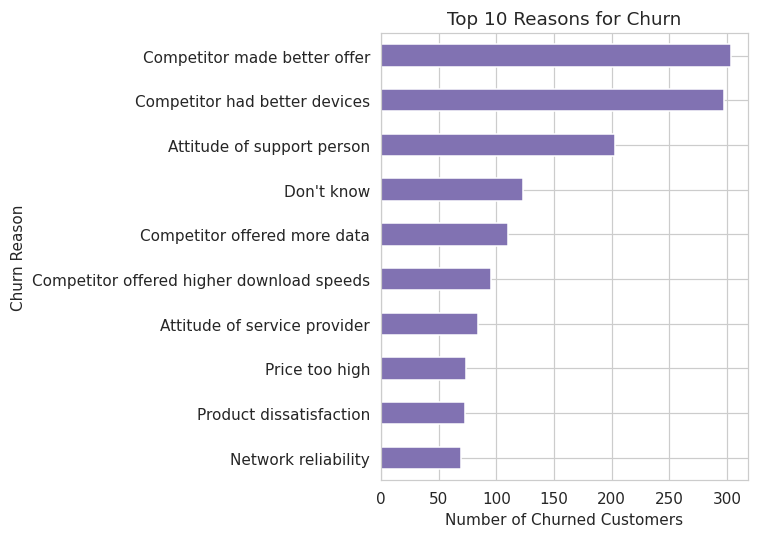

In [ ]:
# Visualization 6: Horizontal bar chart - Top churn reasons among churned customers
fig, ax = plt.subplots(figsize=(7,5))
reason_counts.sort_values().plot(kind='barh', color='#8172B2', ax=ax)
ax.set_xlabel('Number of Churned Customers')
ax.set_title('Top 10 Reasons for Churn')
plt.tight_layout()
plt.show()


**Why it matters for prediction:** While `Churn Reason` can't be used as a predictor (it's only
known *after* churn), it explains the "why" behind the numeric signals above — e.g. the high
`Customer Service Calls` correlation lines up with "Attitude of support person" being a top reason, and
the price-sensitivity we saw in `Monthly Charge` lines up with "Price too high" and competitor-offer
reasons. This closes the loop between the statistical predictors and the business narrative for
management.

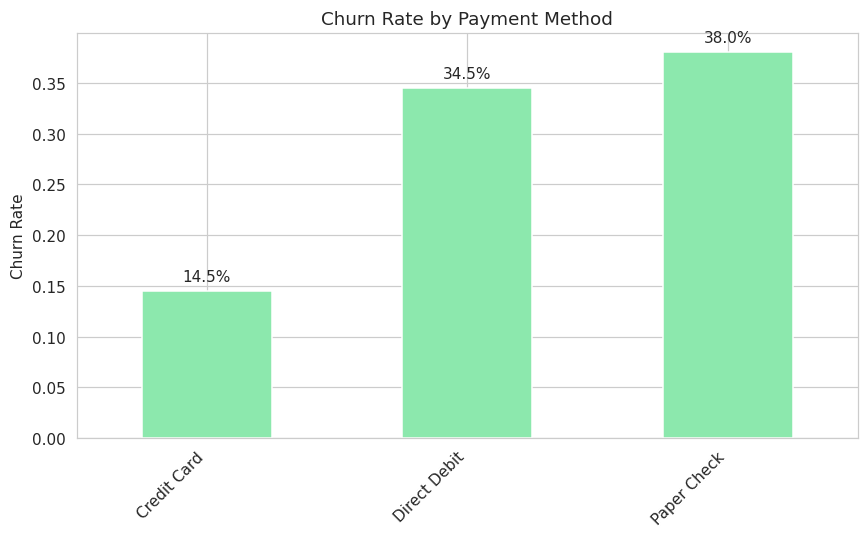

In [ ]:
# Visualization 7: Bar chart - Churn rate by Payment Method
payment_churn = df.groupby('Payment Method')['Churn_Flag'].agg(['mean', 'count']).rename(columns={'mean': 'Churn Rate'}).sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
payment_churn['Churn Rate'].sort_values().plot(kind='bar', color='#8CE8AD', ax=ax)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Payment Method')
ax.set_xlabel('')
for i, v in enumerate(payment_churn['Churn Rate'].sort_values()):
    ax.text(i, v + 0.01, f"{v:.1%}", ha='center')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Why it matters for prediction:** Different payment methods can indicate varying levels of customer engagement or financial stability, which might correlate with churn. For instance, customers using automatic payment methods might exhibit lower churn due to less friction in billing, while those using manual methods could be more prone to disengagement. This can help target interventions based on payment behavior.

/tmp/ipykernel_1948/958714334.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




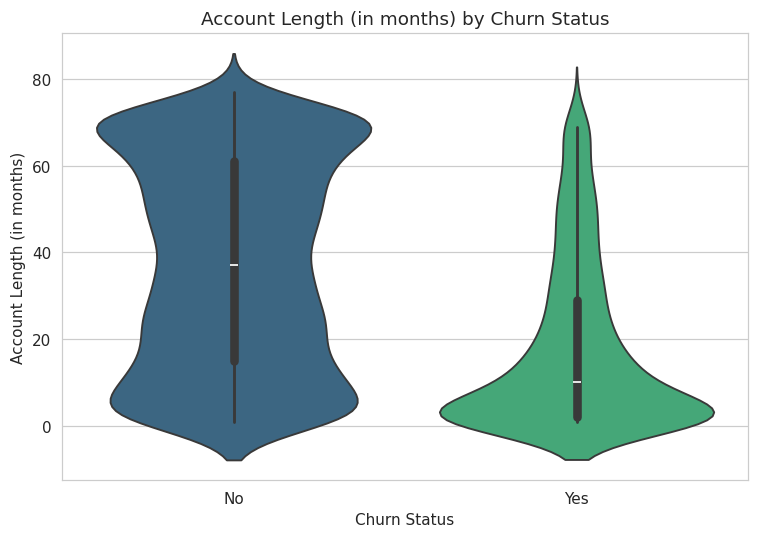

In [ ]:
# Visualization 8: Violin plot - Account Length by Churn Status
fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=df, x='Churn Label', y='Account Length (in months)', palette='viridis', ax=ax)
ax.set_title('Account Length (in months) by Churn Status')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Account Length (in months)')
plt.tight_layout()
plt.show()

### The 'High-Risk' Profile: 3D Multi-Variable Analysis
To provide a truly amazing view of our findings, we visualize the interaction between the three most significant churn drivers: **Monthly Charges**, **Customer Service Calls**, and **Contract Type**.

In [ ]:
import plotly.express as px

# Creating an interactive 3D Scatter plot to show the 'Churn Cluster'
fig = px.scatter_3d(
    df,
    x='Monthly Charge',
    y='Customer Service Calls',
    z='Account Length (in months)',
    color='Churn Label',
    symbol='Contract Type',
    opacity=0.6,
    color_discrete_map={'Yes': '#EF553B', 'No': '#00CC96'},
    title='3D Churn Cluster Analysis: Charges vs. Service Calls vs. Tenure',
    labels={'Monthly Charge': 'Monthly Bill ($)', 'Customer Service Calls': 'Service Calls'}
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    scene=dict(
        xaxis_backgroundcolor="rgb(230, 230,230)",
        yaxis_backgroundcolor="rgb(230, 230,230)",
        zaxis_backgroundcolor="rgb(230, 230,230)"
    )
)

fig.show()

### 3D Cluster Interpretation

This 3D scatter plot visualizes the **intersection of the three most powerful predictors** identified in our analysis:

1.  **The Churn Cluster (The 'Red Zone'):** Observe the dense grouping of red points (churned) at the bottom-right of the plot. This represents customers with **high Monthly Charges** (X-axis) and **high Customer Service Calls** (Y-axis), but with **short Account Length** (Z-axis). This is our primary 'at-risk' profile.
2.  **The Tenure Shield:** As you move higher up the Z-axis (longer tenure), the points transition almost entirely to green (retained), regardless of the monthly charge. This confirms that long-term customers are significantly more resilient to churn.
3.  **Interaction of Service & Cost:** The plot reveals that high costs alone aren't always fatal; however, when high costs are paired with multiple service calls, the probability of churn becomes near-certain for newer customers.

**Actionable Insight:** The most urgent intervention should target customers in their first 12 months who have already made 2+ service calls and have a monthly bill exceeding $50.

### Hierarchical Churn Path: Contract & Payment
This Sunburst chart provides a 'simple but good' interactive view. By clicking on a segment, you can drill down into specific customer paths to see how contract types and payment choices lead to churn.

In [ ]:
import plotly.express as px

# Create a simple but powerful hierarchical view
fig = px.sunburst(
    df,
    path=['Contract Type', 'Payment Method', 'Churn Label'],
    color='Churn Label',
    color_discrete_map={'Yes': '#fc4f30', 'No': '#6d904f'},
    title="Customer Journey: From Contract to Churn"
)

fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
fig.show()

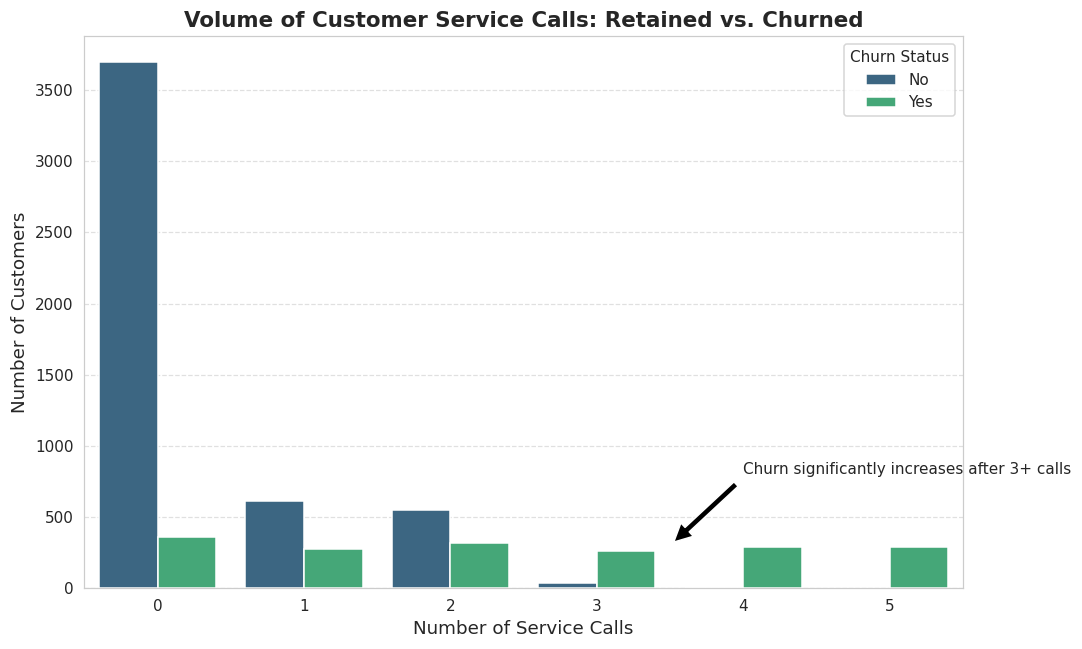

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization 9: Count Plot of Customer Service Calls by Churn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Customer Service Calls', hue='Churn Label', palette='viridis')

plt.title('Volume of Customer Service Calls: Retained vs. Churned', fontsize=14, fontweight='bold')
plt.xlabel('Number of Service Calls', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn Status')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.annotate('Churn significantly increases after 3+ calls',
             xy=(3.5, 300), xytext=(4, 800),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

**Why this matters for prediction:** While the box plot showed the distribution spread, this count plot identifies the specific threshold where churn risk peaks. We can see that the majority of retained customers have 0 calls, while the churned population becomes dominant at 3 or more calls. This provides a clear, actionable threshold for customer success teams to trigger retention interventions.

**Why this is fruitful:**
- **Visual Proportion:** The size of each slice immediately shows you that the 'Month-to-Month' section is the primary source of churn (red slices).
- **Payment Interaction:** You can see at a glance that within 'Month-to-Month', 'Paper Check' has a disproportionately large red slice compared to 'Credit Card'.
- **Simplicity:** No rotating or 3D math required—just a clear map of your customer segments.

**Fruitful Insights from the 3D Plot:**
- **The Red Zone:** Notice how the 'Yes' (red) points cluster heavily in the corner representing high Service Calls (>2) and high Monthly Charges.
- **Contract Layering:** By toggling the symbols, you can see that the 'Month-to-Month' customers occupy almost all of the churned space, whereas long-tenure (high Z-axis) customers are almost exclusively green (retained).

**Why it matters for prediction:** Account length is a critical indicator of customer loyalty and satisfaction. A violin plot effectively displays the distribution of account lengths for both churned and retained customers. We expect to see that churned customers generally have shorter account lengths, indicating that newer customers are more susceptible to churn. This insight is highly valuable for predictive models and for designing early-stage retention programs.

## Summary

- Churn was converted into a numeric flag (`Churn_Flag`) with an overall churn rate of 26.9%.
- Gender and Region show little to no effect on churn; Age/Senior status, Contract Type, and
  Customer Service Calls are the strongest differentiators found.
- The five-plus visualizations above cover categorical drivers (contract, region×senior), behavioral
  signals (service calls, age distribution), a multivariate view (correlation heatmap), and the
  qualitative "why" (churn reasons) — together giving a rounded picture to justify feature choice in
  a subsequent predictive model.
